# Top 5 European Leagues: Player Performance Analysis (2025-2026)

**Dataset:** [Football Players Stats (2025-2026)](https://www.kaggle.com/datasets/hubertsidorowicz/football-players-stats-2025-2026), sourced from FBref. Covers the Premier League, La Liga, Bundesliga, Serie A, and Ligue 1

**How to use this notebook:**
1. Download `players_data-2025_2026.csv` from the Kaggle link above and place it in the same folder as this notebook
2. Run all cells. If the real file isn't found, the notebook falls back to a small synthetic sample with the same real column names (Gls, Ast, Min, 90s, etc.), so everything runs end to end before you plug in the real data.

**Note on columns:** this dataset uses standard FBref abbreviations — `Gls` = Goals, `Ast` = Assists, `Min` = Minutes played, `90s` = minutes / 90 (already pre-calculated), `Pos` = Position, `Squad` = Club, `Comp` = League/Competition.

## 1. Imports and setup

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

csv_file = "players_data-2025_2026.csv"

## 2. Load the data

Loads the real Kaggle CSV if it's present.

In [50]:
def load_data(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"'{path}' not found. Download the real CSV from Kaggle and place it in this notebook's folder, then re-run this cell."
        )
    print(f"Loading dataset from {path}")
    return pd.read_csv(path)

df = load_data(csv_file)
df.head()

Loading dataset from players_data-2025_2026.csv


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,24.0,2000.0,37,30,...,3,0,0,20,51,5,37,17,27,0
1,2,Jerome Abbey,eng ENG,MF,Wolves,eng Premier League,15.0,2009.0,1,0,...,0,0,0,0,0,1,0,1,0,0
2,3,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,3,2,...,0,0,0,3,1,0,3,2,4,0
3,4,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,19.0,2006.0,22,4,...,0,0,0,7,3,2,30,3,3,0
4,5,Himad Abdelli,dz ALG,MF,Marseille,fr Ligue 1,25.0,1999.0,8,1,...,1,0,0,3,0,0,1,2,1,0


## 3. First look at the data

In [51]:
df.shape

(2839, 102)

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2839 entries, 0 to 2838
Columns: 102 entries, Rk to OG
dtypes: float64(45), int64(40), str(17)
memory usage: 2.5 MB


In [53]:
df.describe()

,Rk,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,...,CrdY_stats_misc,CrdR_stats_misc,2CrdY,Fls,Fld,Off,Crs,Int,TklW,OG
count,2839.000000,2837.000000,2837.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,...,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000,2839.000000
mean,1420.000000,24.855834,1999.802256,19.138781,13.576611,1218.580134,13.539803,1.660444,1.159211,2.819655,...,2.412821,0.121169,0.041564,14.497710,13.752730,2.060937,21.657978,10.141951,11.924974,0.045791
std,819.693032,4.623789,4.633160,11.520385,11.225366,963.218994,10.703241,2.932688,1.833065,4.134442,...,2.526406,0.352339,0.204853,13.493894,14.665142,3.801657,34.963118,11.810994,12.430342,0.228399
min,1.000000,15.000000,1983.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,710.500000,21.000000,1997.000000,9.000000,3.000000,320.500000,3.600000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
50%,1420.000000,25.000000,2000.000000,20.000000,12.000000,1074.000000,11.900000,0.000000,0.000000,1.000000,...,2.000000,0.000000,0.000000,12.000000,9.000000,1.000000,6.000000,5.000000,8.000000,0.000000
75%,2129.500000,28.000000,2003.000000,29.000000,23.000000,1972.500000,21.900000,2.000000,2.000000,4.000000,...,4.000000,0.000000,0.000000,23.000000,20.000000,2.500000,26.500000,16.000000,19.000000,0.000000
max,2839.000000,41.000000,2010.000000,38.000000,38.000000,3420.000000,38.000000,36.000000,21.000000,41.000000,...,13.000000,3.000000,2.000000,87.000000,118.000000,41.000000,295.000000,77.000000,72.000000,2.000000


In [54]:
# Let's check the missing values for each column
df.isna().sum().sort_values(ascending=False).head(10)

CS%                    2651
Save%                  2649
SoTA                   2645
Comp_stats_keeper      2645
Born_stats_keeper      2645
MP_stats_keeper        2645
Starts_stats_keeper    2645
Min_stats_keeper       2645
90s_stats_keeper       2645
GA                     2645
dtype: int64

## 4. Cleaning the data

- Let's drop rows for players with 0 minutes played as they would break per-90 stats.
- Let's also only keep the columns relevant to the analysis in this notebook, so it stays readable (even though the real dataset has 102 columns total).

In [55]:
before = len(df)
df = df[df["Min"] > 0].copy()
after = len(df)
print(f"Dropped {before - after} rows with 0 minutes played.")

keep_cols = ["Player", "Nation", "Pos", "Squad", "Comp", "Age",
             "MP", "Min", "90s", "Gls", "Ast", "G+A", "CrdY", "CrdR"]
keep_cols = [c for c in keep_cols if c in df.columns]
df = df[keep_cols].copy()
df.head()

Dropped 0 rows with 0 minutes played.


,Player,Nation,Pos,Squad,Comp,Age,MP,Min,90s,Gls,Ast,G+A,CrdY,CrdR
0,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,24.0,37,2449,27.2,4,5,9,3,0
1,Jerome Abbey,eng ENG,MF,Wolves,eng Premier League,15.0,1,17,0.2,0,0,0,0,0
2,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,3,164,1.8,0,0,0,0,0
3,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,19.0,22,681,7.6,2,0,2,0,0
4,Himad Abdelli,dz ALG,MF,Marseille,fr Ligue 1,25.0,8,138,1.5,0,0,0,1,0


## 5. Feature engineering

Using the dataset's own pre-calculated `90s` column (minutes / 90) to derive **goals per 90** and **assists per 90** — the standard way to compare players who played very different amounts of time.

In [56]:
df["Gls_per90"] = df["Gls"] / df["90s"]
df["Ast_per90"] = df["Ast"] / df["90s"]
df[["Player", "Squad", "Gls", "90s", "Gls_per90", "Ast_per90"]].head()

,Player,Squad,Gls,90s,Gls_per90,Ast_per90
0,Brenden Aaronson,Leeds United,4,27.2,0.147059,0.183824
1,Jerome Abbey,Wolves,0,0.2,0.000000,0.000000
2,Zach Abbott,Nottingham Forest,0,1.8,0.000000,0.000000
3,Jones El-Abdellaoui,Celta Vigo,2,7.6,0.263158,0.000000
4,Himad Abdelli,Marseille,0,1.5,0.000000,0.000000


## 6. Top goal scorers

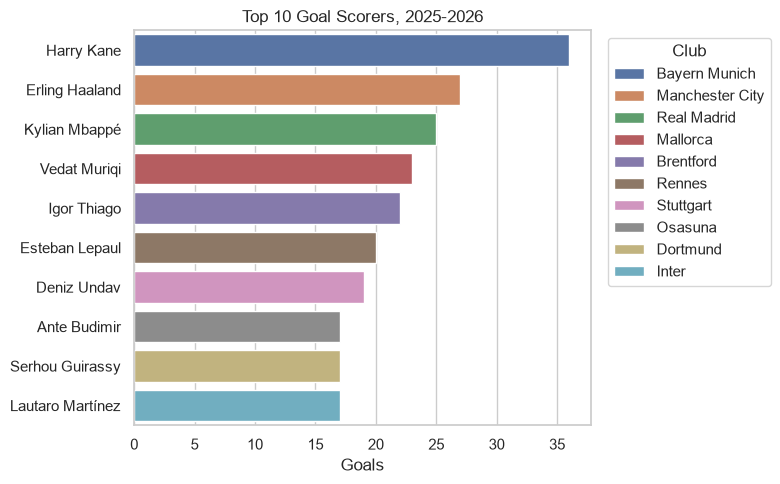

In [57]:
top_n = 10
top = df.nlargest(top_n, "Gls")

plt.figure(figsize=(8, 5))
sns.barplot(data=top, x="Gls", y="Player", hue="Squad", dodge=False)
plt.title(f"Top {top_n} Goal Scorers, 2025-2026")
plt.xlabel("Goals")
plt.ylabel("")
plt.legend(title="Club", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top_scorers.png"), dpi=150)
plt.show()

## 7. Goal contributions by position

Goals + Assists per 90 minutes, grouped by position — checking whether the data shows the expected pattern (forwards contributing most, defenders least).

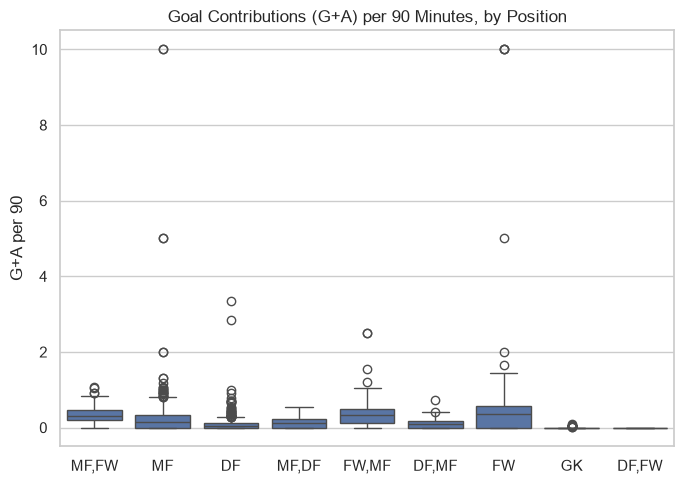

In [58]:
df["GA_per90"] = df["Gls_per90"] + df["Ast_per90"]

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Pos", y="GA_per90")
plt.title("Goal Contributions (G+A) per 90 Minutes, by Position")
plt.xlabel("")
plt.ylabel("G+A per 90")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "contributions_by_position.png"), dpi=150)
plt.show()

## 8. Age vs. output

Let's check for a visible relationship between a player's age and their per-90 output.
Common football-analytics wisdom says output tends to peak in the mid-to-late 20s.

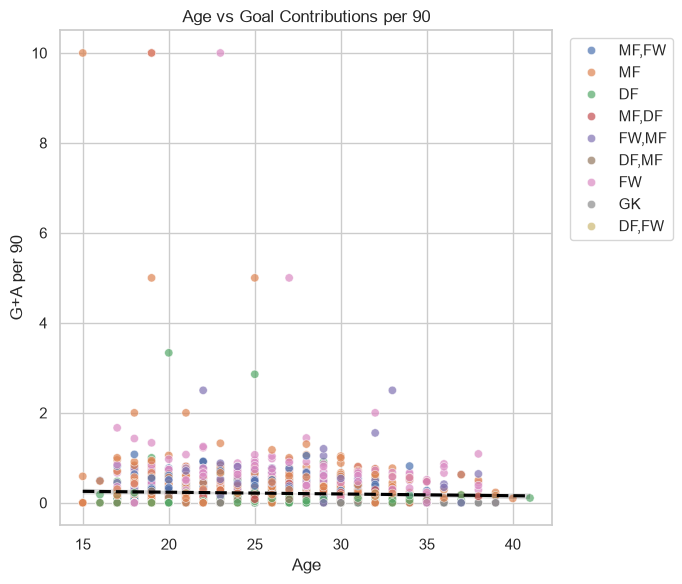

In [59]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x="Age", y="GA_per90", hue="Pos", alpha=0.7)
sns.regplot(data=df, x="Age", y="GA_per90", scatter=False, color="black", line_kws={"linestyle": "--"})
plt.title("Age vs Goal Contributions per 90")
plt.xlabel("Age")
plt.ylabel("G+A per 90")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "age_vs_output.png"), dpi=150)
plt.show()

## 9. Findings

In [60]:
top_scorer = df.loc[df["Gls"].idxmax()]
best_per90 = df[df["90s"] >= 5].loc[df[df["90s"] >= 5]["GA_per90"].idxmax()]

print(f"Top scorer: {top_scorer['Player']} ({top_scorer['Squad']}) "
      f"with {top_scorer['Gls']} goals.")

print(f"Best G+A per 90 (min. 5 full matches played): {best_per90['Player']} "
      f"({best_per90['Squad']}), {best_per90['GA_per90']:.2f} goal contributions per 90.")

print("(The 5-match minimum avoids one-off hot streaks from players with very little "
      "playing time dominating the per-90 ranking.)")

Top scorer: Harry Kane (Bayern Munich) with 36 goals.
Best G+A per 90 (min. 5 full matches played): Harry Kane (Bayern Munich), 1.55 goal contributions per 90.
(The 5-match minimum avoids one-off hot streaks from players with very little playing time dominating the per-90 ranking.)
